# Objective
This case requires trainees to develop a model for predicting fraudulent transactions for a
financial company and use insights from the model to develop an actionable plan. Data for the
case is available in CSV format having 6362620 rows and 10 columns.
Candidates can use whatever method they wish to develop their machine learning model.
Following usual model development procedures, the model would be estimated on the
calibration data and tested on the validation data. This case requires both statistical analysis and
creativity/judgment. We recommend you spend time on both fine-tuning and interpreting the
results of your machine learning model.

# Importing necessary librarys

In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import xgboost
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from sklearn import metrics as metrics

# Data extraction

In [3]:
df = pd.read_csv('/content/Fraud.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(6362620, 11)

# Performing EDA

In [6]:
# Checking null values
df.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


# Observations
## There are very few null values inthe dataset, i will drop those null value records

In [7]:
df = df.dropna()

In [8]:
# Checking duplicate records
df.duplicated().sum()

np.int64(0)

# Observations
## There is no duplicate records in this data

In [9]:
# Data Audit
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


# Performing univariate analysis

In [10]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [11]:
for col in df.columns:
  print(df[col].value_counts())

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
706        4
721        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
amount
10000000.00    3207
10000.00         88
5000.00          79
15000.00         68
500.00           65
               ... 
151849.59         1
341252.72         1
431409.04         1
344148.22         1
258347.61         1
Name: count, Length: 5316900, dtype: int64
nameOrig
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
              ..
C1567523029    1
C644777639     1
C1256645416    1
C1231536757    1
C1971151096    1
Name: count, Length: 6353307, dtype: int64
oldbalanceOrg
0.00         2102449
184.00           918
133.00           914
195.00           912
164.00           909
              ...   
533881.37          1
288393.93   

# Seperating categorical data and numerical data for analysis purpose

In [12]:
cat_df = df.select_dtypes(include='object')
num_df = df.select_dtypes(exclude='object')

In [13]:
cat_df.head()

,type,nameOrig,nameDest
0,PAYMENT,C1231006815,M1979787155
1,PAYMENT,C1666544295,M2044282225
2,TRANSFER,C1305486145,C553264065
3,CASH_OUT,C840083671,C38997010
4,PAYMENT,C2048537720,M1230701703


In [14]:
num_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [15]:
for col in cat_df.columns:
  print(cat_df[col].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
nameOrig
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
              ..
C1567523029    1
C644777639     1
C1256645416    1
C1231536757    1
C1971151096    1
Name: count, Length: 6353307, dtype: int64
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
M367627425       1
M1902904124      1
M242332837       1
M281573812       1
M1010678443      1
Name: count, Length: 2722362, dtype: int64


In [16]:
for i in df.type.unique():
  print(df[df['type']==i]['isFraud'].value_counts())

isFraud
0    2151495
Name: count, dtype: int64
isFraud
0    528812
1      4097
Name: count, dtype: int64
isFraud
0    2233384
1       4116
Name: count, dtype: int64
isFraud
0    41432
Name: count, dtype: int64
isFraud
0    1399284
Name: count, dtype: int64


In [17]:
df.type.value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


/tmp/ipython-input-2577580063.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')


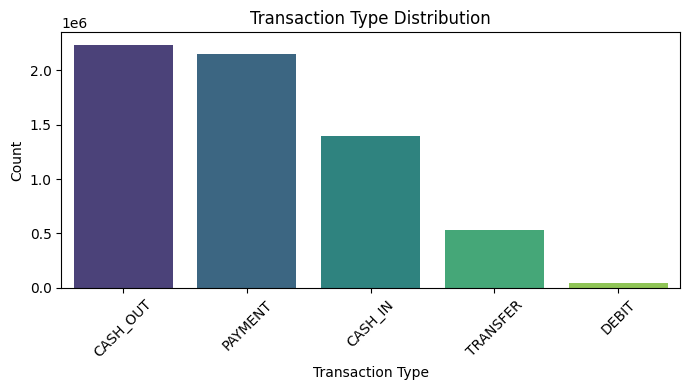

In [18]:
# visualizing the no.of payments
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts
type_counts = df['type'].value_counts()

# Plot
plt.figure(figsize=(7,4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
cat_df.head()

,type,nameOrig,nameDest
0,PAYMENT,C1231006815,M1979787155
1,PAYMENT,C1666544295,M2044282225
2,TRANSFER,C1305486145,C553264065
3,CASH_OUT,C840083671,C38997010
4,PAYMENT,C2048537720,M1230701703


In [20]:
num_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0


# Checking correlation for numerical variables

In [21]:
num_df.corr().T

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


# Visualizing the correlation

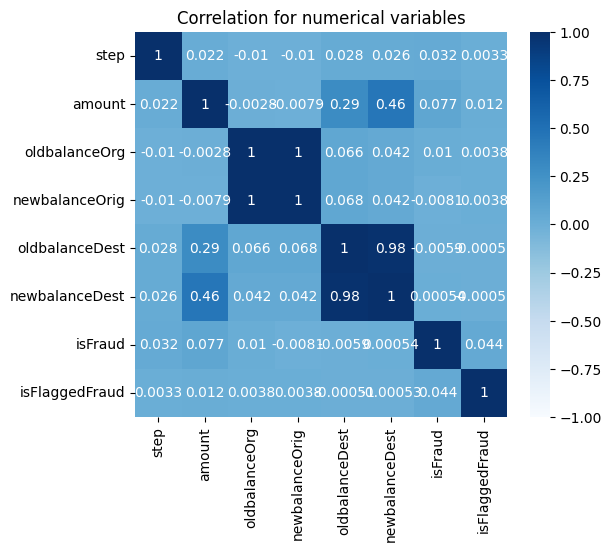

In [22]:
plt.figure(figsize=(6,5))
sns.heatmap(num_df.corr(),vmax=1,vmin=-1,annot=True,cmap='Blues')
plt.title('Correlation for numerical variables')
plt.show()

# Checking Outliers in the dataset

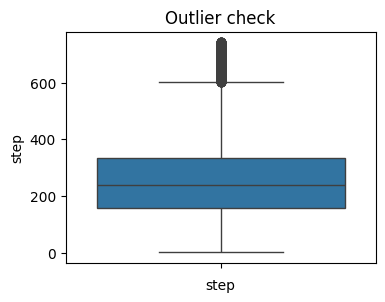

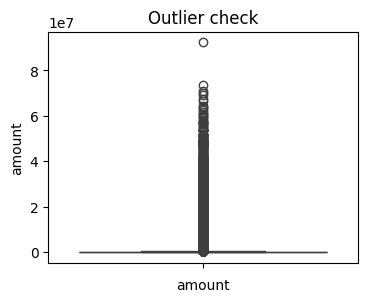

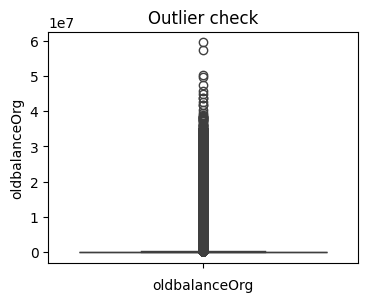

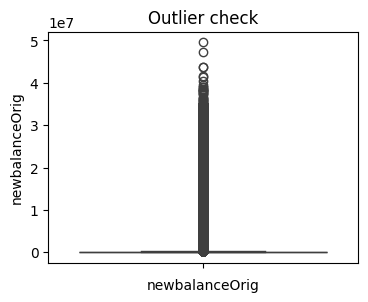

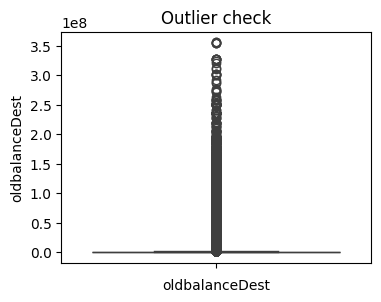

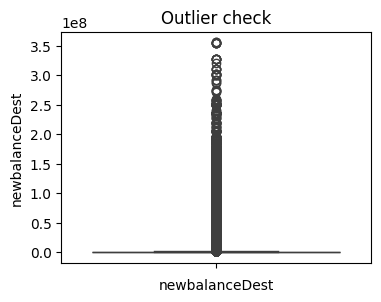

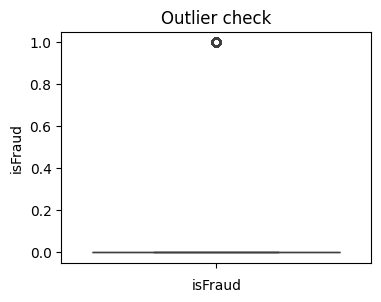

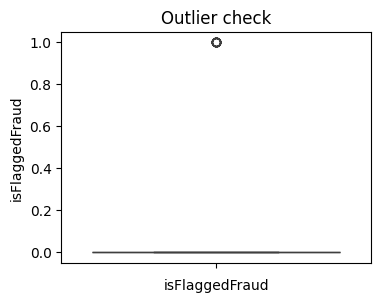

In [23]:
for col in num_df.columns:
  plt.figure(figsize=(4,3))
  sns.boxplot(num_df[col])
  plt.xlabel(col)
  plt.title('Outlier check')
  plt.show()

# Observations
- We observe outliers in the dataset
- we need to to impute outliers with the IQR method

In [24]:
def impute_outliers(x):
  q1 = x.quantile(0.25)
  q3 = x.quantile(0.75)
  iqr = q3-q1
  upper_cut = q3+1.5*iqr
  lower_cut = q1-1.5*iqr
  return x.clip(lower=lower_cut,upper=upper_cut)

In [25]:
num_df = num_df.drop(['isFraud','isFlaggedFraud'],axis=1)

In [26]:
num_df = num_df.apply(impute_outliers)

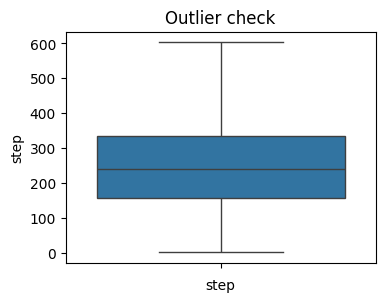

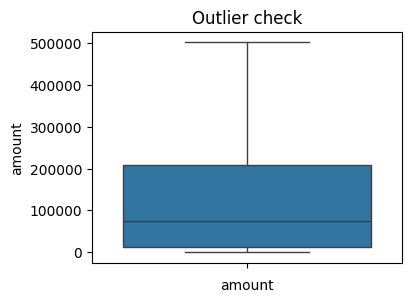

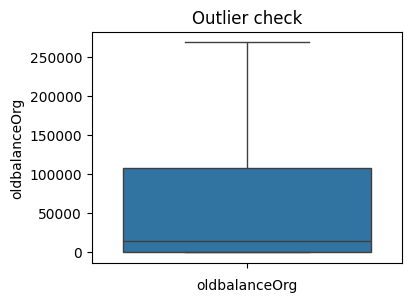

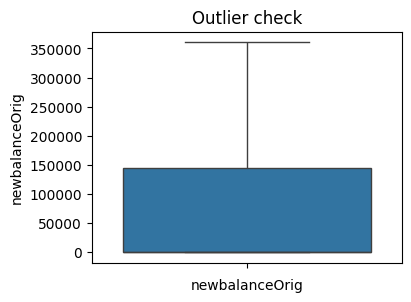

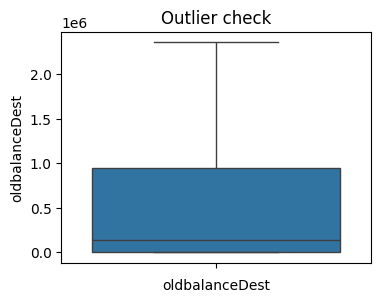

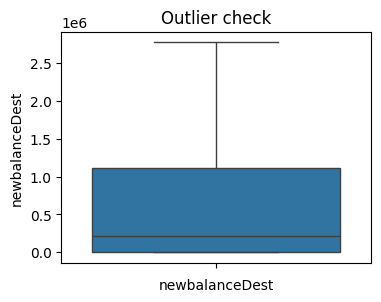

In [27]:
# Verfiy outlier treatment
for col in num_df.columns:
  plt.figure(figsize=(4,3))
  sns.boxplot(num_df[col])
  plt.xlabel(col)
  plt.title('Outlier check')
  plt.show()

In [28]:
num_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1.0,9839.64,170136.0,160296.36,0.0,0.0
1,1.0,1864.28,21249.0,19384.72,0.0,0.0
2,1.0,181.00,181.0,0.00,0.0,0.0
3,1.0,181.00,181.0,0.00,21182.0,0.0
4,1.0,11668.14,41554.0,29885.86,0.0,0.0


# Encoding categorical variables

In [29]:
cat_df.head()

,type,nameOrig,nameDest
0,PAYMENT,C1231006815,M1979787155
1,PAYMENT,C1666544295,M2044282225
2,TRANSFER,C1305486145,C553264065
3,CASH_OUT,C840083671,C38997010
4,PAYMENT,C2048537720,M1230701703


In [30]:
encoder = OneHotEncoder(drop='first')
encoder.fit(cat_df[['type']])

OneHotEncoder(drop='first')

In [31]:
output = encoder.transform(cat_df[['type']])
encoder.get_feature_names_out(['type'])

array(['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype=object)

In [32]:
cat_df = pd.DataFrame(encoder.transform(cat_df[['type']]).toarray(),columns=encoder.get_feature_names_out(['type']))

In [33]:
cat_df.head()

,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


In [34]:
data = pd.concat([num_df,cat_df],axis=1)

In [35]:
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1.0,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,181.00,181.0,0.00,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,0.0,0.0
4,1.0,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
data['isFraud'] = df['isFraud']

In [37]:
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,1.0,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,1.0,0.0,0
1,1.0,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,1.0,0.0,0
2,1.0,181.00,181.0,0.00,0.0,0.0,0.0,0.0,0.0,1.0,1
3,1.0,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,0.0,0.0,1
4,1.0,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,1.0,0.0,0


# Split the data

In [38]:
X = data.drop(['isFraud'],axis=1)
y = data['isFraud']

# Checking Multicollinearity

In [39]:
vif = pd.DataFrame()
vif['variables'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

In [40]:
vif

,variables,VIF
0,step,3.517419
1,amount,3.764823
2,oldbalanceOrg,6.680909
3,newbalanceOrig,8.572098
4,oldbalanceDest,34.425729
5,newbalanceDest,39.021716
6,type_CASH_OUT,3.044688
7,type_DEBIT,1.021613
8,type_PAYMENT,1.833586
9,type_TRANSFER,2.379276


# Observations
- We observe ther is high VIF for 'oldbalanceDest','newbalanceDest'
- we drop one variable i.e'newbalanceDest'

In [41]:
X = X.drop(['newbalanceDest'],axis=1)

In [42]:
# Splitting the dataset into training set, and validation set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.8,random_state=45)

In [43]:
X_test.shape,y_test.shape

((5090096, 9), (5090096,))

In [44]:
y_train.shape,y_train.shape

((1272524,), (1272524,))

# Feature selection using RFE method

In [45]:
X_train.shape

(1272524, 9)

In [46]:
lr = RandomForestClassifier()
rfe = RFE(estimator=lr,n_features_to_select=6)
rfe.fit(X_train,y_train)

RFE(estimator=RandomForestClassifier(), n_features_to_select=6)

In [47]:
pd.DataFrame(data = {'Feature':X_train.columns,'Ranking':rfe.ranking_})

,Feature,Ranking
0,step,1
1,amount,1
2,oldbalanceOrg,1
3,newbalanceOrig,1
4,oldbalanceDest,1
5,type_CASH_OUT,2
6,type_DEBIT,4
7,type_PAYMENT,3
8,type_TRANSFER,1


# top-6 significance features for model
  - step
  - amount
  - oldbalanceOrg
  - newbalanceOrig
  - oldbalanceDest
  - type_CASH_OUT

# First i build model uisng all variables, except variables, which are having high multicollinearity

# Decision Tree Model Implemantation

In [48]:
# Initializing the model
tree = DecisionTreeClassifier()

# Fit the model to training set
tree.fit(X_train,y_train)

# Model predictions on training set
y_train_pred = tree.predict(X_train)

# Model predictions on validation set
y_test_pred = tree.predict(X_test)

In [49]:
# Model validation using classification metrics
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270857
           1       0.99      0.96      0.98      1667

    accuracy                           1.00   1272524
   macro avg       1.00      0.98      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



In [50]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083550
           1       0.71      0.67      0.69      6546

    accuracy                           1.00   5090096
   macro avg       0.85      0.83      0.84   5090096
weighted avg       1.00      1.00      1.00   5090096



In [51]:
acc_train_dt = accuracy_score(y_train,y_train_pred)
acc_test_dt = accuracy_score(y_test,y_test_pred)
print(acc_train_dt)
print(acc_test_dt)

0.9999410620153333
0.9992184823233197


# Observation
- Out Decision tree model tree works well in both Training data and testing data
- Model is generalized
- no overfitting & no underfitting


# RandomForest Model implemantation

In [52]:
forest = RandomForestClassifier()

In [53]:
model= forest.fit(X_train,y_train)
test_predict_rf = model.predict(X_test)
train_predict_rf = model.predict(X_train)

In [54]:
# RandomForest Model evaluation
print(classification_report(y_train,train_predict_rf))  # for training set
print(classification_report(y_test,test_predict_rf))  # for testing set

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270857
           1       0.99      0.97      0.98      1667

    accuracy                           1.00   1272524
   macro avg       0.99      0.98      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083550
           1       0.83      0.61      0.70      6546

    accuracy                           1.00   5090096
   macro avg       0.92      0.80      0.85   5090096
weighted avg       1.00      1.00      1.00   5090096



In [55]:
confusion_matrix(y_train,train_predict_rf)  # for training set


array([[1270835,      22],
       [     53,    1614]])

In [56]:
confusion_matrix(y_test,test_predict_rf)  # for testing set

array([[5082757,     793],
       [   2568,    3978]])

In [57]:
acc_train_rf = accuracy_score(y_train,train_predict_rf)
acc_test_rf = accuracy_score(y_test,test_predict_rf)
print(acc_train_rf)
print(acc_test_rf)

0.9999410620153333
0.9993396981117841


# Implementation of KNN model

In [58]:
# Initializing the model
lr = KNeighborsClassifier()

# fit the model to training set
model1 = lr.fit(X_train,y_train)

# Making predictions on both training & testing set
y_train_pred_knn = model1.predict(X_train)
y_test_pred_knn = model1.predict(X_test)

In [59]:
# Evaluation of KNN model
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270857
           1       0.99      0.96      0.98      1667

    accuracy                           1.00   1272524
   macro avg       1.00      0.98      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



In [60]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083550
           1       0.71      0.67      0.69      6546

    accuracy                           1.00   5090096
   macro avg       0.85      0.83      0.84   5090096
weighted avg       1.00      1.00      1.00   5090096



In [62]:
# confusion matrix for KNN
confusion_matrix(y_train,y_train_pred_knn)

array([[1270679,     178],
       [    828,     839]])

In [63]:
confusion_matrix(y_test,y_test_pred_knn)

array([[5082200,    1350],
       [   3899,    2647]])

# Finding Optimal K value using GridSearchCV

In [64]:
param_grid = {'n_neighbors':[6,6,7,8,9,10,11,12,13,15],'weights':['uniform','distance']}
knn_gcv = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)
knn_gcv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [6, 6, 7, 8, 9, 10, 11, 12, 13, 15],
                         'weights': ['uniform', 'distance']})

In [65]:
knn_gcv.best_params_

{'n_neighbors': 6, 'weights': 'uniform'}

In [66]:
knn_gcv.best_score_

np.float64(0.9990161285463195)

In [67]:
# Implementation of KNN using optimal hyper parameters
knn = KNeighborsClassifier(n_neighbors=11,weights='uniform')
# fit the model to training set
model3 = knn.fit(X_train,y_train)
# Making prediction on training set
y_train_pred_knnH = model3.predict(X_train)
# Making prediction on testing set
y_test_pred_knnH = model3.predict(X_test)

In [68]:
# KNN with Hyper parameters model evaluation
print(classification_report(y_train,y_train_pred_knnH))
print(classification_report(y_test,y_test_pred_knnH))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270857
           1       0.81      0.41      0.55      1667

    accuracy                           1.00   1272524
   macro avg       0.91      0.71      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083550
           1       0.71      0.36      0.48      6546

    accuracy                           1.00   5090096
   macro avg       0.86      0.68      0.74   5090096
weighted avg       1.00      1.00      1.00   5090096



In [69]:
confusion_matrix(y_train,y_train_pred_knnH)  # for training set

array([[1270698,     159],
       [    976,     691]])

In [70]:
confusion_matrix(y_test,y_test_pred_knnH)  # for testing set

array([[5082604,     946],
       [   4209,    2337]])

In [73]:
train_proba = model3.predict_proba(X_train)[:,1]
test_proba = model3.predict_proba(X_test)[:,1]

# Roc curve for training set in KNN model

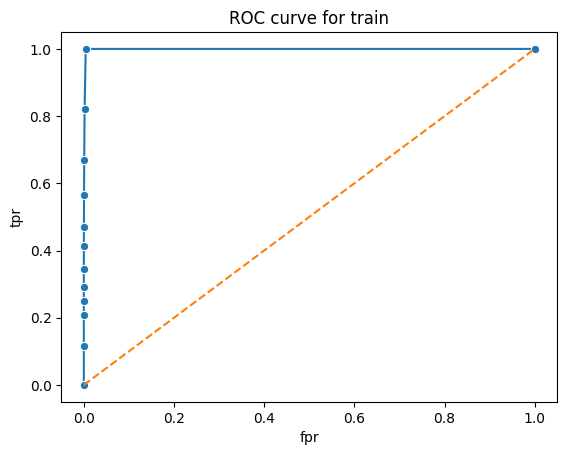

In [75]:
fpr,tpr,thresholds = metrics.roc_curve(y_train,train_proba)
sns.lineplot(x = fpr, y = tpr, marker = 'o')
plt.plot([0,1],[0,1],linestyle = '--')
plt.title('ROC curve for train')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

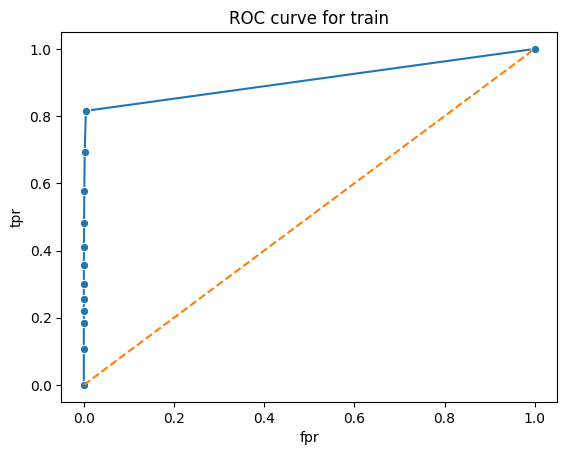

In [74]:
fpr,tpr,thresholds = metrics.roc_curve(y_test,test_proba)
sns.lineplot(x = fpr, y = tpr, marker = 'o')
plt.plot([0,1],[0,1],linestyle = '--')
plt.title('ROC curve for train')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

# Conclusion
The objective of the problem is to build a model which can predict fraudulent transactions.
- I build a model with focusing on Classificaiton tasks
- I build Decision Tree Classifier got 99% accuracy in both training and testing
- I build RandomForest Classifier, got 99% accuracy in both training and testing
- I build KNN, it got 99% accuracy in both training and testing.
in above three models, i choose RandomForest model for real world application, why because, it is more generalized model.
A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.

# Questions and answers

1. Data cleaning including missing values, outliers and multi-collinearity.
2. Describe your fraud detection model in elaboration.
3. How did you select variables to be included in the model?
4. Demonstrate the performance of the model by using best set of tools.
5. What are the key factors that predict fraudulent customer?
6. Do these factors make sense? If yes, How? If not, How not?
7. What kind of prevention should be adopted while company update its infrastructure?
8. Assuming these actions have been implemented, how would you determine if they work?

# 1.Data cleaning including missing values, outliers and mutli-collinearity
In data cleaning
- missing values:
  There is few records which have only less missing values
  i simply drop those values
  if it has more missing values, few techniques are available
  - for numerical variable missing records i impute them with "mean" and "Median"
  - for categorical variable missing records i impute them with "mode"
  - and also i have an option to choose KNN imputer using sklearn LibraryLoader
- outliers
  - firstly i check outliers using boxplot
  - it displays outlers in the visual represenation for every column
  - then i use IQR method to perfrom outlier treatment
  - then i recheck the outliers using boxplot for verification purpose.
- Multicollinearity
  - i check multicollinearity using Variance Inflation Factor
  - VIF technique which is widely used method to detect multicollinearity,
  - It give VIF values for each variable
  - if VIF > 5 i drop those Variables

#2. Describe your fraud detection model in elaboration.
- My model is all about detecting fraud customer using transaction data
- first thing is getting appropriate data
- data check,data cleaning
- data preprocessing
    - checking correlation
    - checking outliers
    - checking multicollinearity(VIF)
    - EDA
- Selecting important/significant features
    choose best and important features using RFE method
- Split the data into training & testing set
    split the data into two parts, one part for model training, and another part for testing which will ensure our model ability
    is our model perform better or not in unseen data.
-  model implementation
    - There are various classification model available in ML
    - but primarily i choose DecisionTreeClassifier,RandomForestClassifier,KNeighborsClassifier
    - which are used for classification tasks, which will find patterns and memorize those patterns and apply those in unseen data, than it predicts a cusotmer is fraud or not
- Fit the model to training set
- Make prediction on testing set
- Evaluate the model using classification metrics classification report, confusion matrix, accuracy score
- Ensure your model performace based on the accuracy score in both training and testing.

from math import remainder
# 3.How did you select variables to be included in the model?
I select variables for the model using RFE mehtod
- Using RFE method
  - it is a feature selection method
  - it considers all features
  - and build the model, and calculates the importance of the features
  - removes the least importance features
  - then build the model using remaining features
  - then calcualte the feature importance
  - then remove the least importance feature
  - repeats the process until it reaches the required number of features, which user specified

# 4.Demonstrate the performance of the model by using best set of tools.
I demonstrate the performance of the model usng evaluation metrics
- The evaluation metrics access the model performance
- For classification model i choose "Classification Reort" & "Confusion Report" as evaluation metrics
- Which provide detail explanation about Accuracy,Precision,Recall,F1_score for each class
- I calculate the these for both training set & testing set
- then i compare the both results
- if accuracy is good in both training and testing then i choose that model

I improve the model by tuning hyper parameters using GridSearchCv
  - GridSearchCV is the technique used to findout best combination of the parameter values.
  - it improves the model performance by finding and applying in the model
  - and it contains cross validation which helps to get more generalizable model.

# 5.What are the key factors that predict fraudulent customer?
One of the key factors that predict fraudulent customer 'type',oldbalanceDest','newbalanceDest'
- The type variable is the most key factors in predictiong fradulent customer.

# 6. Do these factors make sense? If yes, How? If not, How not?
Yes these factors do make sense.
these factors contains most significant data, which will ensure the particular transaction is fraud or not.
- This factors include, payment type,  oldbalanceDest, newbalanceDest  based on these will predict the fraud or not.

# 7. What kind of prevention should be adopted while company update its infrastructure?
- The following are the few important preventions company should take
  - Data safety.
  - data integrity
  - Company data

#8. Assuming these actions have been implemented, how would you determine if they work?
If these actions have been implemented, i would determine the work by thourougly check the model parameter values, and model evaluation metrics.
- i compare the results with the previous records
- if it will match, i simply say that these actions have been implemented.

# End of the model work